In [2]:
import fsps
import matplotlib.pyplot as plt
from ceridwen.ssps.ssp_data import SSPData
import jax.numpy as jnp

ssp_data = SSPData.load('/Users/amanda/Desktop/PhD/Tools/ceridwen/ceridwen/data/test_data/ssp_data.h5')

sp = fsps.StellarPopulation(zcontinuous=0, zmet=2, sfh =0, add_neb_emission=False, add_neb_continuum=False)


In [140]:
sp.params['add_neb_emission'] = False
sp.params['add_neb_continuum'] = False

wave, fsps_spec_no_neb = sp.get_spectrum(tage=0.001)

sp.params['add_neb_emission'] = True
sp.params['add_neb_continuum'] = True
sp.params['gas_logz'] = 0
sp.params['gas_logu'] = -4
wave, fsps_spec_with_neb = sp.get_spectrum(tage=0.001)


sp.params['add_neb_emission'] = True
sp.params['add_neb_continuum'] = False
wave, fsps_spec_only_lines = sp.get_spectrum(tage=0.001)


fsps_spec_only_cont = fsps_spec_with_neb - fsps_spec_only_lines


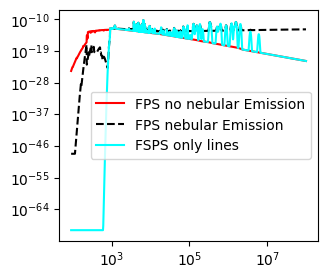

In [4]:
plt.figure(figsize = (10/3, 3))
plt.loglog(wave, fsps_spec_no_neb, color='red', label='FPS no nebular Emission')
plt.loglog(wave, fsps_spec_with_neb, color='black', ls = 'dashed', label='FPS nebular Emission')
plt.loglog(wave, fsps_spec_only_lines, color = 'cyan', label = 'FSPS only lines')
plt.legend()



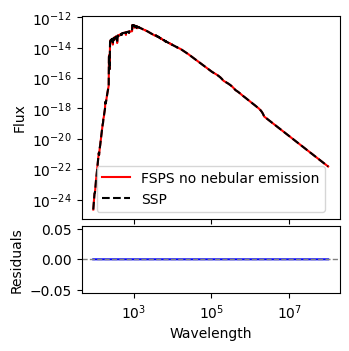

In [55]:

age_idx = 21  # Corresponds to 1 Myr
met_idx = 1

# Extract the model and SSP spectrum
ssp_flux = ssp_data.ssp_flux[met_idx, age_idx, :]

residuals = (fsps_spec_no_neb - ssp_flux) / ssp_flux

# Create two vertically stacked subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10/3, 3.6), sharex=True,
                               gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05})

# Top plot: Spectra
ax1.loglog(wave, fsps_spec_no_neb, color='red', label='FSPS no nebular emission')
ax1.loglog(wave, ssp_flux, color='black', ls='dashed', label='SSP')
#ax1.set_ylim(1e-17, 1e-12)
#ax1.set_xlim(1e2, 1e5)
ax1.legend()
ax1.set_ylabel("Flux")

# Bottom plot: Normalized residuals
ax2.plot(wave, residuals, color='blue')
ax2.axhline(0, color='gray', lw=1, ls='--')
ax2.set_ylabel("Residuals")
ax2.set_xlabel("Wavelength")

plt.show()

In [161]:

import jax.numpy as jnp
from pathlib import Path
from jax import vmap, jit
#from jax.scipy.interpolate import interp1d
import numpy as np
import astropy.constants as const
import math



from pathlib import Path
import jax.numpy as jnp

class NebularModel:
    def __init__(self,sps_home, csp_lambda, cloudy_dust = False,  isoc_type='mist',
                smooth_velocity=True, nebnz=11, nebnage=10, nebnip=7, nebular_smooth_init=100.0):
        """
        Initializes a nebular emission model for use with stellar population synthesis output.

        Parameters
        ----------
        isoc_type : str
            Isochrone type (e.g., 'mist', 'pdva', 'bpss') used to identify the correct nebular files.
        cloudy_dust : bool
            If True, uses nebular models with dust attenuation from CLOUDY.
        sps_home : str or Path
            Path to the FSPS root directory containing the nebular subdirectory.
        csp_lambda : array-like
            Wavelength grid of the composite stellar population (CSP) spectrum [in Angstrom].
.
        jnp.pi : float
            Value of π (can be jnp.pi or float).
        smooth_velocity : bool, optional
            If True, smoothing is velocity-based (km/s). If False, use fixed smoothing in Å.
        nebnz : int, optional
            Number of metallicity grid points.
        nebnage : int, optional
            Number of age grid points.
        nebnip : int, optional
            Number of ionization parameter grid points.
        nebular_smooth_init : float, optional
            Initial smoothing width in km/s or Å (depending on `smooth_velocity`).
        """

        # Store CSP wavelength grid and spectrum length
        self.csp_lambda = jnp.asarray(csp_lambda)
        self.nspec = self.csp_lambda.size

        self.smooth_velocity = smooth_velocity
        self.nebular_smooth_init = nebular_smooth_init
        self.nebnz = nebnz
        self.nebnage = nebnage
        self.nebnip = nebnip

        # Set filenames for nebular continuum and line emission based on isochrone type and dusty flag
        suffix = 'WD' if cloudy_dust else 'ND'
        base = Path(sps_home) / 'nebular' / f'ZAU_{suffix}_{isoc_type}'
        self.cont_file = base.with_suffix('.cont')   # Nebular continuum file
        self.line_file = base.with_suffix('.lines')  # Nebular emission line file

        # Load the nebular continuum cube and grids
        self._load_continuum()

        # Load the nebular emission line cube and line positions
        self._load_lines()

        # Compute the minimum spectral resolution for each line (in Å)
        self._compute_resolution_elements()

        # Build Gaussian line profiles for all emission lines on the CSP wavelength grid
        self._build_gaussians()

    def __repr__(self):
        def _shape(x):
            try:
                return tuple(jnp.asarray(x).shape)
            except Exception:
                try:
                    return tuple(np.asarray(x).shape)
                except Exception:
                    return "n/a"

        def _minmax(x):
            try:
                xa = jnp.asarray(x)
                return f"{float(jnp.min(xa)):.4g} – {float(jnp.max(xa)):.4g}"
            except Exception:
                return "n/a"

        lines = []
        lines.append("<NebularModel>")
        lines.append("-----------------------------------")
        # Config
        lines.append(f"Files:")
        lines.append(f"  Continuum: {str(self.cont_file)}")
        lines.append(f"  Lines    : {str(self.line_file)}")
        lines.append("")
        lines.append("Grids & settings:")
        lines.append(f"  CSP λ grid shape        : {_shape(self.csp_lambda)}  (nspec={getattr(self, 'nspec', 'n/a')})")
        lines.append(f"  smooth_velocity         : {self.smooth_velocity}")
        lines.append(f"  nebular_smooth_init     : {self.nebular_smooth_init}")
        lines.append(f"  nebnz / nebnage / nebnip: {getattr(self, 'nebnz', 'n/a')} / {getattr(self, 'nebnage', 'n/a')} / {getattr(self, 'nebnip', 'n/a')}")
        lines.append("")
        # Continuum cube + parameter grids
        lines.append("Continuum cube (log10 L/Q):")
        lines.append(f"  nebem_cont shape        : {_shape(getattr(self, 'nebem_cont', None))}  (nspec, nz, nage, nu)")
        lines.append(f"  nebem_logz shape/range  : {_shape(getattr(self, 'nebem_logz', None))} ; {_minmax(getattr(self, 'nebem_logz', None))}")
        lines.append(f"  nebem_age  shape/range  : {_shape(getattr(self, 'nebem_age', None))}  ; {_minmax(getattr(self, 'nebem_age', None))}  (log10 yr)")
        lines.append(f"  nebem_logu shape/range  : {_shape(getattr(self, 'nebem_logu', None))} ; {_minmax(getattr(self, 'nebem_logu', None))}")
        lines.append("")
        # Lines cube
        lines.append("Emission lines (log10 L/Q):")
        lines.append(f"  line positions shape    : {_shape(getattr(self, 'nebem_line_pos', None))}  (Å)")
        lines.append(f"  nebem_line shape        : {_shape(getattr(self, 'nebem_line', None))}  (nlines, nz, nage, nu)")
        lines.append(f"  neb_res_min shape/range : {_shape(getattr(self, 'neb_res_min', None))} ; {_minmax(getattr(self, 'neb_res_min', None))}  (Å)")
        lines.append("")
        # Precomputed Gaussians
        lines.append("Precomputed line profiles:")
        lines.append(f"  gaussnebarr shape       : {_shape(getattr(self, 'gaussnebarr', None))}  (nspec, nlines)")
        lines.append("")
        # Last evaluation (if present)
        lines.append("Last evaluation buffers (optional):")
        lines.append(f"  conflux shape           : {_shape(getattr(self, 'conflux', None))}")
        lines.append(f"  lineflux shape          : {_shape(getattr(self, 'lineflux', None))}")
        lines.append(f"  linespec shape          : {_shape(getattr(self, 'linespec', None))}")

        return "\n".join(lines)

    def _load_continuum(self): 
        # Open the nebular continuum file and skip the header
        with open(self.cont_file, 'r') as f:
            f.readline()  # skip header line

            # Read the wavelength grid of the nebular continuum model
            readlambneb = np.array([float(x) for x in f.readline().split()])
            nlam = len(readlambneb)
            self.readlambneb = jnp.asarray(readlambneb)

            # Read the rest of the file content into memory
            lines = f.readlines()

            # Allocate arrays for interpolated continuum and parameter grids
            cont_cube = np.zeros((self.nspec, self.nebnz, self.nebnage, self.nebnip))
            logz_grid = np.zeros(self.nebnz)   # gas metallicity
            logu_grid = np.zeros(self.nebnip)  # ionization parameter
            age_grid = np.zeros(self.nebnage)  # age in yr

            idx = 0  # line index in the file
            for i in range(self.nebnz):
                for j in range(self.nebnage):
                    for k in range(self.nebnip):
                        # First line gives (logZ, age, logU) for this cube slice
                        parts = [float(x) for x in lines[idx].split()]
                        logz_grid[i], age_grid[j], logu_grid[k] = parts[:3]
                        idx += 1

                        # Second line gives the continuum spectrum (Lsun/Hz/Q)
                        cont = np.array([float(x) for x in lines[idx].split()])
                        logcont = np.log10(cont + 10**-95)  # avoid log(0)
                        # Interpolate onto CSP wavelength grid
                        cont_interp = jnp.interp(self.csp_lambda, readlambneb, logcont)
                        cont_cube[:, i, j, k] = cont_interp
                        idx += 1

        # Store as JAX arrays for GPU compatibility
        self.nebem_cont = jnp.asarray(cont_cube)
        self.nebem_logz = jnp.asarray(logz_grid)
        self.nebem_logu = jnp.asarray(logu_grid)
        self.nebem_age = jnp.log10(jnp.asarray(age_grid))  # log10(age/yr)
    
    def _load_lines(self):
        # Open the nebular emission line file
        with open(self.line_file, 'r') as f:
            f.readline()  # Skip header line

            # Read the rest-frame line center wavelengths (in Å)
            self.nebem_line_pos = jnp.array([float(x) for x in f.readline().split()])
            self.nemline = self.nebem_line_pos.shape[0]

            # Allocate array to store log10(line luminosities) in Lsun/Q
            line_cube = np.zeros((self.nemline, self.nebnz, self.nebnage, self.nebnip))

            # Loop over metallicity, age, and ionization parameter grid
            for i in range(self.nebnz):
                for j in range(self.nebnage):
                    for k in range(self.nebnip):
                        f.readline()  # metadata line (logZ, age, logU), already known
                        linevals = np.array([float(x) for x in f.readline().split()])
                        # Store log10(L/Q), avoiding log(0)
                        line_cube[:, i, j, k] = np.log10(linevals + 10**-95)

            # Store line emission cube as a JAX array for GPU use
            self.nebem_line = jnp.asarray(line_cube)

    
    def _compute_resolution_elements(self):
        '''Avoid delta function spikes in nebular lines when the broadening of the gaussian is smaller than the resolution element.'''
        # For each emission line, find the nearest wavelength index just below the line center
        idx = jnp.clip(jnp.searchsorted(self.csp_lambda, self.nebem_line_pos) - 1, 1, self.nspec - 2)
        dlam_left  = self.csp_lambda[idx]   - self.csp_lambda[idx - 1]
        dlam_right = self.csp_lambda[idx+1] - self.csp_lambda[idx]
        self.neb_res_min = 0.5 * (dlam_left + dlam_right)

    
    def _build_gaussians(self):
        """
        Precompute normalized Gaussian line profiles for each emission line,
        on the given wavelength grid. These profiles model the line broadening
        (either in velocity space or wavelength space), and are stored for
        later use when adding line emission to the SED.
        """

        def compute_line(i):
            lam0 = self.nebem_line_pos[i]
            dlam = jnp.where(
                self.smooth_velocity,
                lam0 * self.nebular_smooth_init / (const.c *10**10)* 1e13,  # in Angstrom
                self.nebular_smooth_init
            )
            dlam = jnp.maximum(dlam, self.neb_res_min[i] * 2.0)

            norm = 1.0 / (jnp.sqrt(2 * jnp.pi) * dlam)
            profile = jnp.exp(-0.5 * ((self.csp_lambda - lam0) / dlam) ** 2)
            scaling = lam0 ** 2 / (const.c * 10**10)

            return norm * profile * scaling  # shape: (n_lambda,)

        # Vectorize over all emission lines
        self.gaussnebarr = jnp.stack([compute_line(i) for i in range(self.nebem_line_pos.shape[0])], axis=1)
        return self.gaussnebarr  # shape: (n_lambda, n_lines)

    def evaluate(self, logZ, logU, logage, logQ):

        # Locate and compute fractional offsets in grid
        z1 = jnp.searchsorted(self.nebem_logz, logZ)#locate(logZ, self.nebem_logz)
        dz = jnp.clip((logZ - self.nebem_logz[z1]) / (self.nebem_logz[z1 + 1] - self.nebem_logz[z1]), 0.0, 1.0)
        print('z', logZ, z1, self.nebem_logz[z1])

        u1 = jnp.searchsorted(self.nebem_logu, logU)#locate(logU, self.nebem_logu)
        du = jnp.clip((logU - self.nebem_logu[u1]) / (self.nebem_logu[u1 + 1] - self.nebem_logu[u1]), 0.0, 1.0)
        print('u', logU, u1, "neben u1", self.nebem_logu[u1], "neben u1+1", self.nebem_logu[u1+1])
        
        a1 = jnp.searchsorted(self.nebem_age, logage)#locate(logage, self.nebem_age)
        da = jnp.clip((logage - self.nebem_age[a1]) / (self.nebem_age[a1 + 1] - self.nebem_age[a1]), 0.0, 1.0)

        # Interpolate log-continuum and line luminosity
        logcont_interp = trilinear(self.nebem_cont, z1, dz, a1, da, u1, du)
        loglines_interp = trilinear(self.nebem_line, z1, dz, a1, da, u1, du)

        # Combine with logQ
        log_cont_flux = logcont_interp + logQ
        log_line_flux = loglines_interp + logQ
        
        # Convert to linear only where absolutely necessary
        cont_flux = 10 ** log_cont_flux  # shape (nspec,)
        line_flux = 10 ** log_line_flux  # shape (nlines,)
        
        # Combine lines
        line_spec = jnp.dot(self.gaussnebarr, line_flux)   # shape (nspec,)
        self.linespec = line_spec  # Store for later use if needed
        self.conflux = cont_flux  # Store for later use if needed
        self.lineflux = line_flux  # Store for later use if needed


        return cont_flux, line_spec

def locate(x, grid):
    return jnp.clip(jnp.searchsorted(grid, x) - 1, 0, grid.size - 2)   

def trilinear_interp(cube, z1, dz, a1, da, u1, du):
    """
    Trilinear interpolation on a 4D cube: shape (nspec, nz, nage, nu)
    """
    # Interpolation weights for the 8 surrounding points
    w = jnp.array([
        (1 - dz) * (1 - da) * (1 - du),
        (1 - dz) * (1 - da) * du,
        (1 - dz) * da * (1 - du),
        (1 - dz) * da * du,
        dz * (1 - da) * (1 - du),
        dz * (1 - da) * du,
        dz * da * (1 - du),
        dz * da * du
    ])

    # Stack the 8 corners along a new axis (0), each of shape (nspec,)
    slices = jnp.stack([
        cube[:, z1,   a1,   u1],
        cube[:, z1,   a1,   u1+1],
        cube[:, z1,   a1+1, u1],
        cube[:, z1,   a1+1, u1+1],
        cube[:, z1+1, a1,   u1],
        cube[:, z1+1, a1,   u1+1],
        cube[:, z1+1, a1+1, u1],
        cube[:, z1+1, a1+1, u1+1]
    ], axis=0)  # shape (8, nspec)

    # Weighted sum over the 8 corners
    return jnp.sum(w[:, None] * slices, axis=0)  # shape (nspec,)


def trilinear(cube, z1, dz, a1, da, u1, du):
    return (
        (1 - dz) * (1 - da) * (1 - du) * cube[:, z1,   a1,   u1  ] +
        (1 - dz) * (1 - da) * (    du) * cube[:, z1,   a1,   u1+1] +
        (1 - dz) * (    da) * (1 - du) * cube[:, z1,   a1+1, u1  ] +
        (1 - dz) * (    da) * (    du) * cube[:, z1,   a1+1, u1+1] +
        (    dz) * (1 - da) * (1 - du) * cube[:, z1+1, a1,   u1  ] +
        (    dz) * (1 - da) * (    du) * cube[:, z1+1, a1,   u1+1] +
        (    dz) * (    da) * (1 - du) * cube[:, z1+1, a1+1, u1  ] +
        (    dz) * (    da) * (    du) * cube[:, z1+1, a1+1, u1+1]
    )

In [174]:

model = NebularModel(
    sps_home="/Users/amanda/Prospector/fsps",
    csp_lambda=wave,
    nebular_smooth_init=200,
    smooth_velocity=True,
    cloudy_dust=True
)

cont, line = model.evaluate(
    logZ=sp.params['gas_logz'],
    logU=sp.params['gas_logu'],
    logage=ssp_data.ssp_lg_age_gyr[age_idx] + 9,  # Example age in log years
    logQ=ssp_data.log_qq[met_idx, age_idx]  # Example ionizing photon rate
)

spec = cont + line


mod_age_idx = jnp.searchsorted(model.nebem_age, ssp_data.ssp_lg_age_gyr[age_idx] + 9)
mod_met_idx = jnp.searchsorted(model.nebem_logz, sp.params['gas_logz'])
mod_logu_idx = jnp.searchsorted(model.nebem_logu, sp.params['gas_logu'])

z 0.0 8 0.0
u -4 0 neben u1 -4.0 neben u1+1 -3.5


In [175]:
model.neb_res_min

Array([1.0000000e+01, 1.0000000e+01, 1.0000000e+01, 1.0000000e+01,
       1.0000000e+01, 1.0000000e+01, 1.0000000e+01, 1.0000000e+01,
       1.0000000e+01, 1.0000000e+01, 1.0000000e+01, 1.0000000e+01,
       1.0000000e+01, 1.0000000e+01, 1.0000000e+01, 8.5000000e+00,
       1.0000000e+01, 1.0000000e+01, 1.0000000e+01, 1.0000000e+01,
       1.0000000e+01, 1.0000000e+01, 1.0000000e+01, 1.0000000e+01,
       1.0000000e+01, 1.0000000e+01, 1.0000000e+01, 1.0000000e+01,
       1.0000000e+01, 1.0000000e+01, 1.0000000e+01, 1.0000000e+01,
       1.0000000e+01, 1.0000000e+01, 2.0000000e+01, 2.0000000e+01,
       2.0000000e+01, 9.0026855e-01, 9.0026855e-01, 9.0026855e-01,
       9.0026855e-01, 9.0026855e-01, 9.0026855e-01, 9.0026855e-01,
       9.0026855e-01, 9.0026855e-01, 9.0039062e-01, 9.0026855e-01,
       9.0039062e-01, 9.0014648e-01, 9.0039062e-01, 9.0039062e-01,
       9.0039062e-01, 9.0014648e-01, 9.0014648e-01, 9.0039062e-01,
       9.0014648e-01, 9.0014648e-01, 9.0039062e-01, 9.0039062e

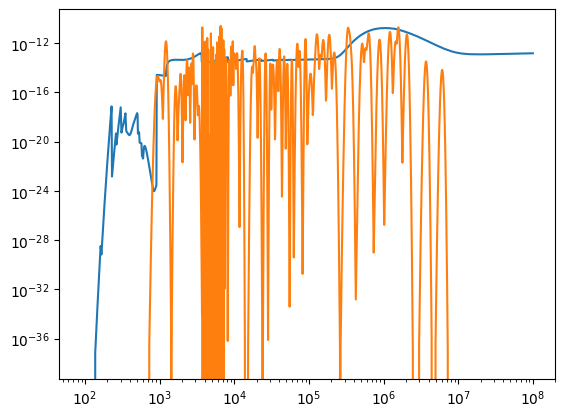

In [176]:
plt.loglog(wave, cont, label="Continuum")
plt.loglog(wave, line, label="Lines")

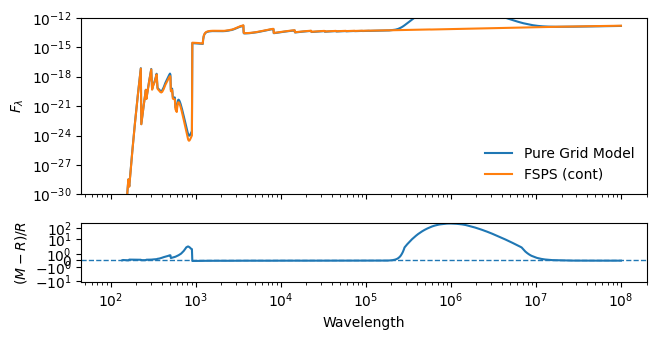

In [177]:
see = 10**(model.nebem_cont[:, mod_met_idx, mod_age_idx, mod_logu_idx] + ssp_data.log_qq[met_idx, age_idx])
residual = (see - fsps_spec_only_cont) / fsps_spec_only_cont

fig, (ax_spec, ax_res) = plt.subplots(
    2, 1,
    figsize=(20/3, 3.5),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]}
)

# --- Top panel: spectra ---
ax_spec.loglog(wave, see, label="Pure Grid Model")
ax_spec.loglog(wave, fsps_spec_only_cont, label="FSPS (cont)")
ax_spec.set_ylabel(r"$F_\lambda$")
ax_spec.legend(frameon=False)
ax_spec.set_ylim(1e-30, 1e-12)

# --- Bottom panel: residual ---
ax_res.semilogx(wave, residual)
ax_res.axhline(0.0, linestyle="--", linewidth=1)
ax_res.set_ylabel(r"$(M - R)/R$")
ax_res.set_yscale('symlog')
ax_res.set_xlabel(r"Wavelength")

plt.tight_layout()
plt.show()

In [166]:
nebem_logz = model.nebem_logz
nebem_logu = model.nebem_logu
nebem_age = model.nebem_age

In [167]:
logZ=sp.params['gas_logz']
logU=sp.params['gas_logu']
logage = ssp_data.ssp_lg_age_gyr[age_idx] + 9

z1 = jnp.searchsorted(nebem_logz, logZ)
dz = (logZ - nebem_logz[z1]) / (nebem_logz[z1 + 1] - nebem_logz[z1])
dz = jnp.clip(dz, 0.0, 1.0)

u1 = jnp.searchsorted(nebem_logu, logU)
du = (logU - nebem_logu[u1]) / (nebem_logu[u1 + 1] - nebem_logu[u1])
du = jnp.clip(du, 0.0, 1.0)

a1 = jnp.searchsorted(nebem_age, logage)
da = jnp.clip((logage - nebem_age[a1]) / (nebem_age[a1 + 1] - nebem_age[a1]), 0.0, 1.0)



def trilinear_interp(cube, z1, dz, a1, da, u1, du):
    """
    Trilinear interpolation on a 4D cube: shape (nspec, nz, nage, nu)
    """
    # Interpolation weights for the 8 surrounding points
    w = jnp.array([
        (1 - dz) * (1 - da) * (1 - du),
        (1 - dz) * (1 - da) * du,
        (1 - dz) * da * (1 - du),
        (1 - dz) * da * du,
        dz * (1 - da) * (1 - du),
        dz * (1 - da) * du,
        dz * da * (1 - du),
        dz * da * du
    ])
    return w


w_cont = trilinear_interp(model.nebem_cont, z1, dz, a1, da, u1, du)

w_cont

Array([1., 0., 0., 0., 0., 0., 0., 0.], dtype=float32)

In [168]:
ssp_flux = np.array(ssp_data.ssp_flux[met_idx, age_idx, :].copy())

# Zero out ionizing photon flux (below Lyman limit)
ssp_flux[wave < 912] = 0.0

csp_cont = cont + ssp_flux
csp_lines = line + ssp_flux


direct = 10**(model.nebem_cont[:, mod_met_idx, mod_age_idx, mod_logu_idx]+ssp_data.log_qq[met_idx, age_idx])


/var/folders/vd/kv9mg1cx6tdfwmlfx2m5qfr80000gp/T/ipykernel_58053/698425539.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


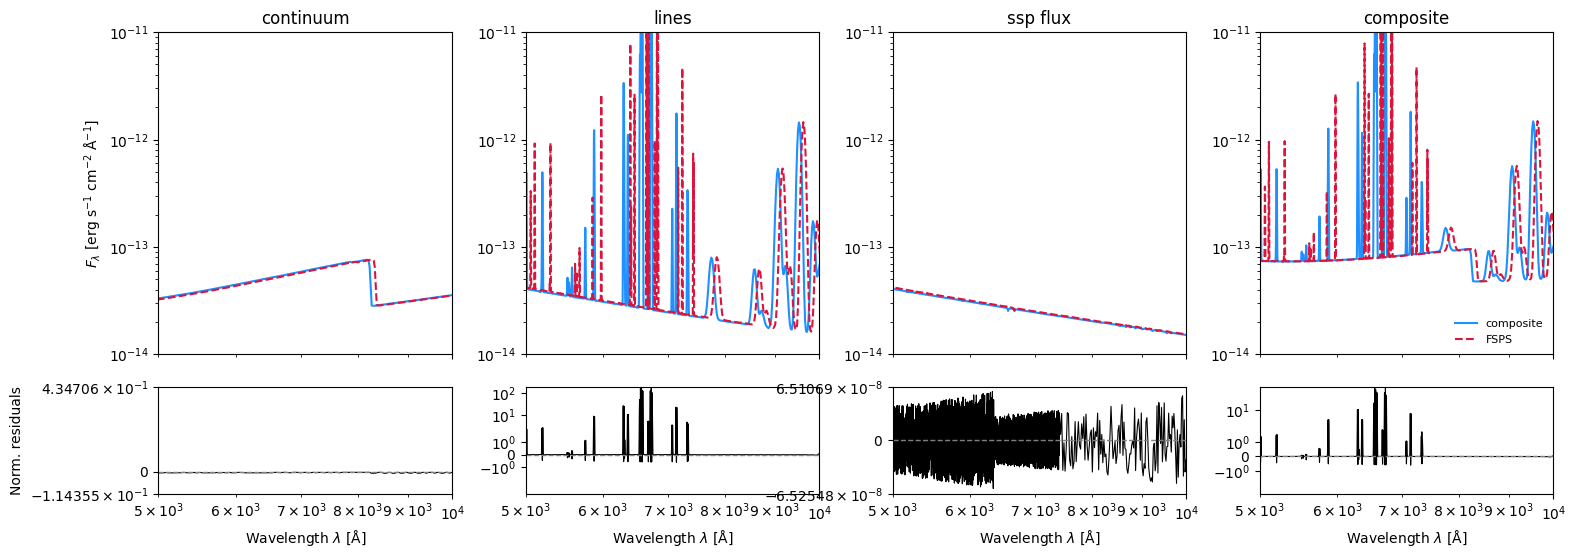

In [173]:
csp_flux = spec + ssp_flux

comparisons = [
    ("continuum", direct, fsps_spec_only_cont, "darkorange"),
    ("lines", csp_lines, fsps_spec_only_lines, "mediumseagreen"),
    ("ssp_flux", np.array(ssp_data.ssp_flux[met_idx, age_idx, :].copy()), fsps_spec_no_neb, "royalblue"),
    ("composite", csp_flux, fsps_spec_with_neb, "crimson")
]


fig, axes = plt.subplots(
    2, len(comparisons), figsize=(18, 6),
    sharex='col', gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.15, 'wspace': 0.25}
)

for i, (label, model_spec, fsps_spec, color) in enumerate(comparisons):
    # --- top: spectra ---
    ax1 = axes[0, i]
    ax1.loglog(wave, model_spec, color='dodgerblue', label=label)
    ax1.loglog(wave + 100, fsps_spec, color='crimson', ls='--', label='FSPS')
    ax1.set_ylim(1e-14, 1e-11)
    ax1.set_xlim(5e3, 1e4)
    ax1.set_title(label.replace('_', ' '))
    if i == 0:
        ax1.set_ylabel(r'$F_\lambda$ [erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$]')
    if i == 3:
        ax1.legend(frameon=False, fontsize=8, loc='lower right')

    # --- bottom: normalized residuals ---
    ax2 = axes[1, i]
    residual = (model_spec - fsps_spec) / fsps_spec
    ax2.plot(wave, residual, color='black', lw=0.8)
    ax2.axhline(0, color='gray', lw=1, ls='--')
    ax2.set_yscale('symlog')
    if i == 0:
        ax2.set_ylabel('Norm. residuals')
    ax2.set_xlabel(r'Wavelength $\lambda$ [Å]')



plt.tight_layout()
plt.show()

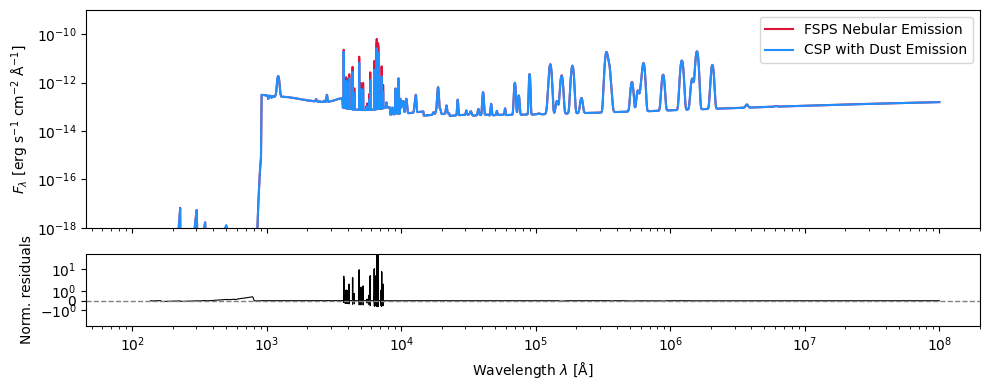

In [135]:
# compute composite flux
csp_flux = spec + ssp_flux

# compute normalized residuals
residuals = (csp_flux - fsps_spec_with_neb) / fsps_spec_with_neb


# plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 4), sharex=True,
                               gridspec_kw={'height_ratios': [3, 1]})

# --- Top: spectra ---

ax1.loglog(wave, fsps_spec_with_neb, color='crimson', label='FSPS Nebular Emission')
ax1.loglog(wave, csp_flux, color='dodgerblue', label='CSP with Dust Emission')
ax1.set_ylim(1e-18, 1e-9)
ax1.legend()
ax1.set_ylabel(r'$F_\lambda\ \mathrm{[erg\ s^{-1}\ cm^{-2}\ \AA^{-1}]}$')

# --- Bottom: residuals ---
ax2.plot(wave, residuals, color='black', lw=0.8)
ax2.axhline(0, color='gray', lw=1, ls='--')
ax2.set_yscale('symlog')
ax2.set_xlabel(r'Wavelength $\lambda$ [Å]')
ax2.set_ylabel('Norm. residuals')

plt.tight_layout()
plt.show()

z -4.0 0 -1.98
u -4 0 neben u1 -4.0 neben u1+1 -3.5
z -3.5 0 -1.98
u -4 0 neben u1 -4.0 neben u1+1 -3.5
z -3.0 0 -1.98
u -4 0 neben u1 -4.0 neben u1+1 -3.5
z -2.5 0 -1.98
u -4 0 neben u1 -4.0 neben u1+1 -3.5
z -2.0 0 -1.98
u -4 0 neben u1 -4.0 neben u1+1 -3.5
z -1.5 1 -1.5
u -4 0 neben u1 -4.0 neben u1+1 -3.5
z -1.0 2 -0.98
u -4 0 neben u1 -4.0 neben u1+1 -3.5
z -0.5 4 -0.39
u -4 0 neben u1 -4.0 neben u1+1 -3.5
z 0.0 8 0.0
u -4 0 neben u1 -4.0 neben u1+1 -3.5


ValueError: x and y must have same first dimension, but have shapes (5994,) and (2, 5994)

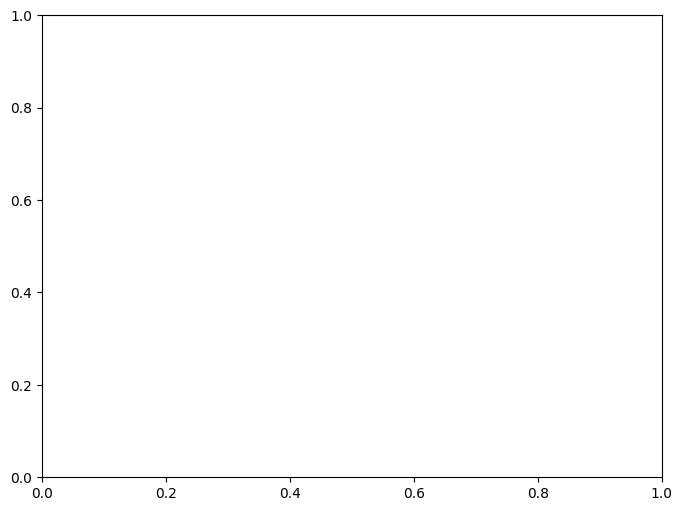

In [28]:
# define metallicity grid
gas_logz_vals = np.linspace(-4, 0, 9)   # or use step=0.5, adjust as you prefer

# prepare storage
all_specs = []
all_fsps_specs = []
all_residuals = []

# zero out ionising flux below 912 Å in your SSP flux
ssp_flux_mod = np.array(ssp_data.ssp_flux[met_idx, age_idx, :].copy())
ssp_flux_mod[wave < 912] = 0.0

# loop over metallicities
for gas_logz in gas_logz_vals:
    sp.params['add_neb_emission'] = True
    sp.params['add_neb_continuum'] = True
    sp.params['gas_logz'] = gas_logz

    # get FSPS spectrum with nebular emission
    wave, fsps_spec_with_neb = sp.get_spectrum(tage=0.001)

    # evaluate your model at same metallicity
    spec = model.evaluate(
        logZ=gas_logz,
        logU=sp.params['gas_logu'],
        logage=ssp_data.ssp_lg_age_gyr[age_idx],
        logQ=ssp_data.log_qq[met_idx, age_idx]
    ) + ssp_flux_mod

    # compute normalized residuals
    residual = (spec - fsps_spec_with_neb) / fsps_spec_with_neb

    # store everything
    all_specs.append(spec)
    all_fsps_specs.append(fsps_spec_with_neb)
    all_residuals.append(residual)

# convert to arrays for easier handling
all_specs = jnp.array(all_specs)
all_fsps_specs = jnp.array(all_fsps_specs)
all_residuals = jnp.array(all_residuals)

# -------------------
# Plot all residuals
# -------------------
plt.figure(figsize=(8,6))

for i, gas_logz in enumerate(gas_logz_vals):
    plt.plot(wave, all_residuals[i], label=fr'$\log Z_\mathrm{{gas}}={gas_logz:.1f}$', lw=1)

plt.axhline(0, color='gray', lw=1, ls='--')
plt.xscale('log')
plt.yscale('symlog')
plt.xlabel(r'Wavelength $\lambda$ [Å]')
plt.ylabel('Normalised residuals')
plt.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

ValueError: x and y must have same first dimension, but have shapes (5994,) and (2, 5994)

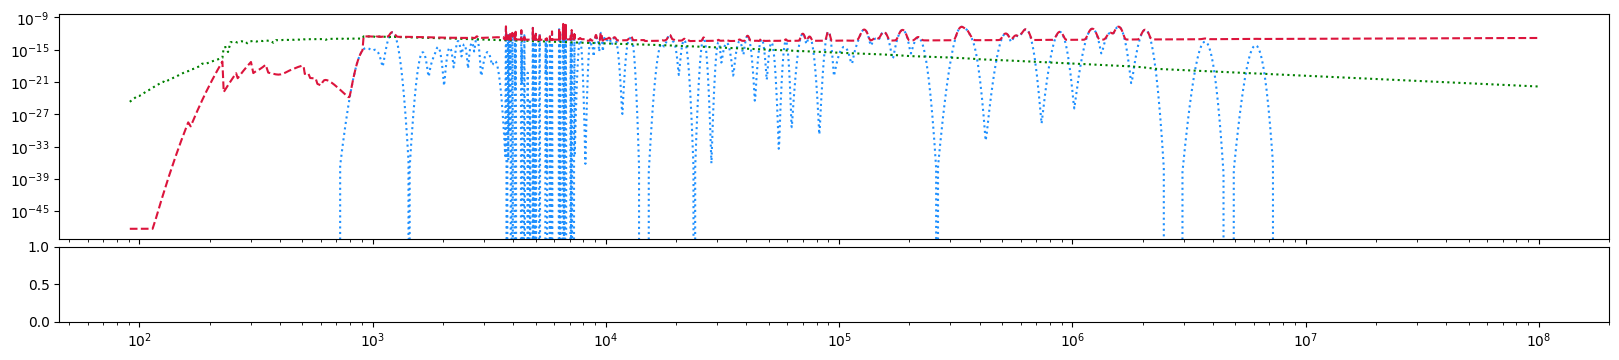

In [26]:
model_flux = fsps_spec_with_neb
data_flux = spec + ssp_data.ssp_flux[met_idx, age_idx, :]

# Compute normalized residual
residual = (model_flux - data_flux) / data_flux

# Set up the figure with two subplots: main and residuals
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(60/3, 4), 
                               gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05},
                               sharex=True)

# Top plot: fluxes
ax1.loglog(wave, model.linespec, color='dodgerblue', ls='dotted', label='Line Flux')
ax1.loglog(wave, fsps_spec_with_neb, color='crimson', ls='--', label='FSPS Nebular Emission', zorder=100)
ax1.loglog(wave, ssp_data.ssp_flux[met_idx, age_idx, :], color='green', ls='dotted', label='SSP Data Flux')
ax1.loglog(wave, data_flux, color='purple', ls='-', label='CSP + SSP Data Flux')
ax1.axvline(912, color='gray', ls='--', label='Lyman Limit (912 Å)')
ax1.set_ylim(1e-28, 1e-10)
ax1.legend()
ax1.set_ylabel("Flux")

# Bottom plot: residuals
ax2.plot(wave, residual, color='black')
ax2.axhline(0, color='gray', lw=1, ls='--')
ax2.set_xscale('log')
ax2.set_xlabel("Wavelength (Å)")
ax2.set_ylabel("Norm. Residual")

plt.show()

In [27]:
ssp_data.log_qq.shape

(12, 108)